# NOTE:
# This notebook was originally executed from:
# /content/drive/MyDrive/notebooks/
# Paths may need to be adjusted if executed from a different directory.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Concatenate



Connection to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Getting the dataframe from the drive

In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df3.csv')
df3

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %,tcc,tclw,sin_h,cos_h,sin_doy,cos_doy
0,2021-07-29 00:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,39.964287,0.153527,0.000000,1.000000,-0.455907,-0.890028
1,2021-07-29 00:15:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,35.300870,0.130069,0.000000,1.000000,-0.455907,-0.890028
2,2021-07-29 00:30:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,30.637451,0.106611,0.000000,1.000000,-0.455907,-0.890028
3,2021-07-29 00:45:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,25.974033,0.083153,0.000000,1.000000,-0.455907,-0.890028
4,2021-07-29 01:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.21,15.70,2.96,94.50,21.310616,0.059695,0.258819,0.965926,-0.455907,-0.890028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125659,2025-05-11 22:45:00,0.0,0.0,0.000331,0.00617,0.000835,0.0,0.0,1.0,0.0,17.28,10.68,0.00,88.15,98.551765,0.000439,-0.500000,0.866025,0.774884,-0.632103
125660,2025-05-11 23:00:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.412260,0.000063,-0.258819,0.965926,0.774884,-0.632103
125661,2025-05-11 23:15:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.502030,0.000048,-0.258819,0.965926,0.774884,-0.632103
125662,2025-05-11 23:30:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.591800,0.000033,-0.258819,0.965926,0.774884,-0.632103


Features of initial df

In [ ]:
df3.shape

(125664, 20)

In [ ]:
df3.dtypes

,0
Time,object
Front POA1 (W/m2),float64
Front POA2 (W/m2),float64
Rear 1 (W/m2),float64
Rear 2 (W/m2),float64
Rear 3 (W/m2),float64
G,float64
W,float64
B,float64
S,float64


In [ ]:
df3['Time']=pd.to_datetime(df3['Time'],format='%Y-%m-%d %H:%M:%S')


Vector of time gaps for window size=96 (1 day)

In [ ]:
time_gaps=[9888, 28416, 67584, 70272, 30144, 85440, 87264,87360, 97728, 105888]

Correlation

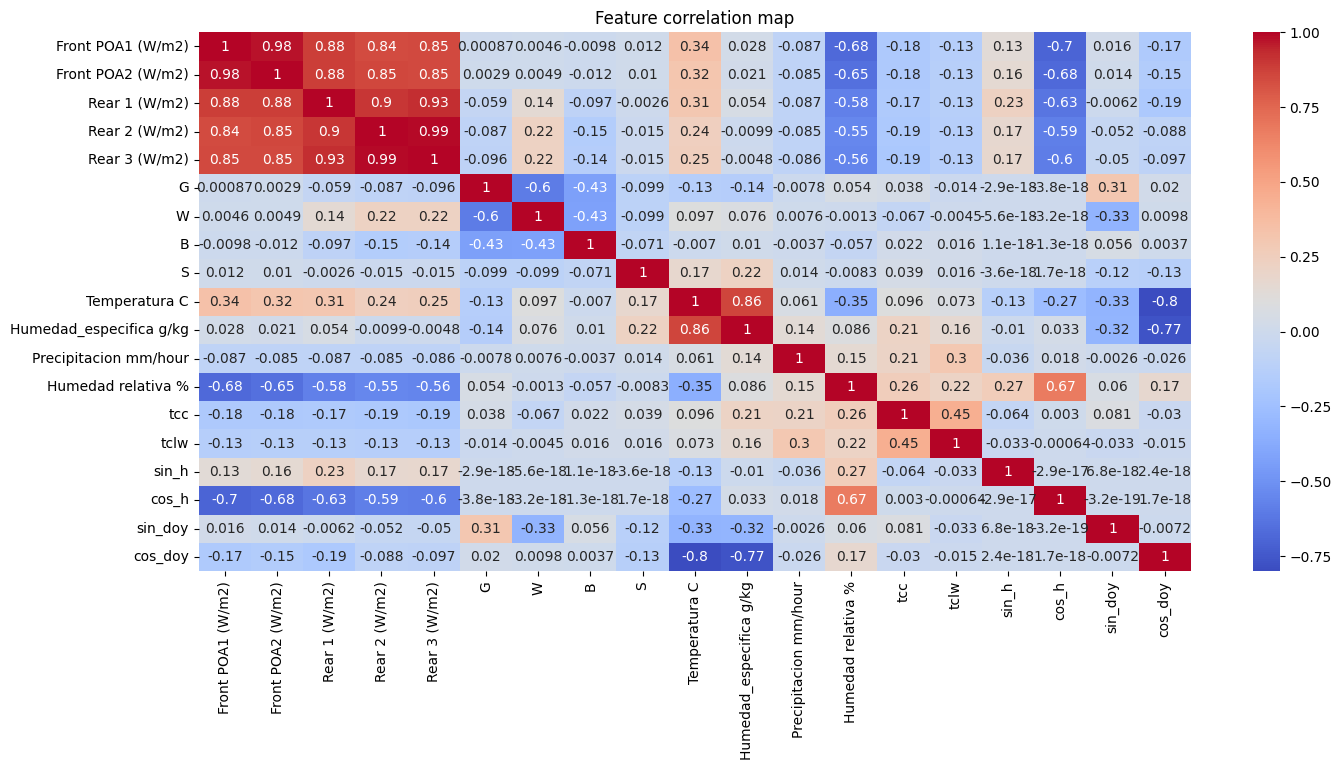

In [ ]:
data_corr=df3.select_dtypes(include=["float64"])
plt.figure(figsize=(16,7))
sns.heatmap(data_corr.corr(),annot=True,cmap="coolwarm")
plt.title("Feature correlation map")
plt.show()

Define seed

In [ ]:
import os
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED']=str(42)

Define parameters

In [ ]:
n_exo_var=5  #[2,3,4,5],
#2=[T,relative_humidity],
#3=[T,relative_humidity,tcc],
#4=[T,relative_humidity, tcc ,precipitation]
#5=[T,relative_humidity, tcc, precipitation, specific humidity]
win_size=96 #[4,8,12,16,20,24,....,96,...192,...]
#It is the window that you want to predict, have in mind that t=15min, so win_size=4 means 1 hour
obs_window=384 #[96,192,288,384,480,576,672,...]
#It is the information of the past that you are using to predict
#obs_window=96,192,288, means 1 day, 2 days and 3 days respectively
gap_setting=0 #[96,192,288]
#it is the space (gap) between the last data and the start of horizon

Define window size for POA1, POA2, Rear 1, Rear 2, Rear3

In [ ]:
def df_to_x_y(window_size,lookback,n_exo,gap_set):
  df_ref=pd.DataFrame({'POA1':np.reshape(df3['Front POA1 (W/m2)'],(df3['Front POA1 (W/m2)'].shape[0]))})
  df_ref['POA2']=df3['Front POA2 (W/m2)']
  df_ref['Rear1']=df3['Rear 1 (W/m2)']
  df_ref['Rear2']=df3['Rear 2 (W/m2)']
  df_ref['Rear3']=df3['Rear 3 (W/m2)']

  df_ref['temp']=df3['Temperatura C']
  df_ref['hum']=df3['Humedad relativa %']

  if n_exo==3:
    df_ref['tcc']=df3['tcc']
  if n_exo==4:
    df_ref['tcc']=df3['tcc']
    df_ref['prep']=df3['Precipitacion mm/hour']
  if n_exo==5:
    df_ref['tcc']=df3['tcc']
    df_ref['prep']=df3['Precipitacion mm/hour']
    df_ref['esp']=df3['Humedad_especifica g/kg']

  df_ref['sin_h']=df3['sin_h']
  df_ref['cos_h']=df3['cos_h']
  df_ref['sin_doy']=df3['sin_doy']
  df_ref['cos_doy']=df3['cos_doy']
  df_ref['G']=df3['G']
  df_ref['W']=df3['W']
  df_ref['B']=df3['B']
  df_ref['S']=df3['S']

  X=[]
  y=[]
  future_albedo=[]
  i=0
  #future data vs past data
  while i<=len(df_ref)-lookback-window_size-gap_set:
    if n_exo==2:
      X_past=df_ref[['POA1','POA2','Rear1','Rear2','Rear3','temp','hum','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    if n_exo==3:
      X_past=df_ref[['POA1','POA2','Rear1','Rear2','Rear3','temp','hum','tcc','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    if n_exo==4:
      X_past=df_ref[['POA1','POA2','Rear1','Rear2','Rear3','temp','hum','tcc','prep','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values
    if n_exo==5:
      X_past=df_ref[['POA1','POA2','Rear1','Rear2','Rear3','temp','hum','tcc','prep','esp','sin_h','cos_h','sin_doy','cos_doy','G','W','B','S']][i:(i+lookback)].values

    X.append(X_past)
    y.append(df_ref[['POA1','POA2','Rear1','Rear2','Rear3']][(i+lookback+gap_set):(lookback+window_size+i+gap_set)])
    future_albedo.append(df_ref[['G','W','B','S']].iloc[(i+lookback+gap_set+48),:])

    if (lookback+window_size+i+gap_set) in time_gaps:
      if (lookback+window_size+i+gap_set)==87264:
        i=i+window_size*(2+int(lookback/window_size))
      else:
        i=i+window_size*(1+int(lookback/window_size))
    else:
      i=i+window_size

  return np.array(X),np.array(y),np.array(future_albedo)

X1_POA_Rear,y1_POA_Rear,surfaces_Rear=df_to_x_y(window_size=win_size,lookback=obs_window,n_exo=n_exo_var,gap_set=gap_setting)

print(X1_POA_Rear.shape)
print(y1_POA_Rear.shape)
print(surfaces_Rear.shape)

(1268, 384, 18)
(1268, 96, 5)
(1268, 4)


Define Training, validation and testing

In [ ]:
XR_POA_Rear_train=X1_POA_Rear[:int(X1_POA_Rear.shape[0]*0.8)]
yR_POA_Rear_train=y1_POA_Rear[:int(y1_POA_Rear.shape[0]*0.8)]
surf_Rear_train=surfaces_Rear[:int(surfaces_Rear.shape[0]*0.8)]

XR_POA_Rear_val=X1_POA_Rear[int(X1_POA_Rear.shape[0]*0.8):int(X1_POA_Rear.shape[0]*0.9)]
yR_POA_Rear_val=y1_POA_Rear[int(y1_POA_Rear.shape[0]*0.8):int(y1_POA_Rear.shape[0]*0.9)]
surf_Rear_val=surfaces_Rear[int(surfaces_Rear.shape[0]*0.8):int(surfaces_Rear.shape[0]*0.9)]

XR_POA_Rear_test=X1_POA_Rear[int(X1_POA_Rear.shape[0]*0.9):]
yR_POA_Rear_test=y1_POA_Rear[int(y1_POA_Rear.shape[0]*0.9):]
surf_Rear_test=surfaces_Rear[int(surfaces_Rear.shape[0]*0.9):]

XR_POA_Rear_train.shape,yR_POA_Rear_train.shape,XR_POA_Rear_val.shape,yR_POA_Rear_val.shape,XR_POA_Rear_test.shape,yR_POA_Rear_test.shape


((1014, 384, 18),
 (1014, 96, 5),
 (127, 384, 18),
 (127, 96, 5),
 (127, 384, 18),
 (127, 96, 5))

In [ ]:
surf_Rear_train.shape,surf_Rear_val.shape,surf_Rear_test.shape

((1014, 4), (127, 4), (127, 4))

Implement MinMaxScaler

In [ ]:
np_POA1_fit=XR_POA_Rear_train[XR_POA_Rear_train[:,:,0]>0.01]
np_POA2_fit=XR_POA_Rear_train[XR_POA_Rear_train[:,:,1]>0.01]
np_Rear1_fit=XR_POA_Rear_train[XR_POA_Rear_train[:,:,2]>0.01]
np_Rear2_fit=XR_POA_Rear_train[XR_POA_Rear_train[:,:,3]>0.01]
np_Rear3_fit=XR_POA_Rear_train[XR_POA_Rear_train[:,:,4]>0.01]

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler_POA1=MinMaxScaler().fit(np_POA1_fit.reshape(-1,1))
scaler_POA2=MinMaxScaler().fit(np_POA2_fit.reshape(-1,1))
scaler_Rear1=MinMaxScaler().fit(np_Rear1_fit.reshape(-1,1))
scaler_Rear2=MinMaxScaler().fit(np_Rear2_fit.reshape(-1,1))
scaler_Rear3=MinMaxScaler().fit(np_Rear3_fit.reshape(-1,1))

scaler_Temp=MinMaxScaler().fit(XR_POA_Rear_train[:,:,5].reshape(-1,1))
scaler_Hum=MinMaxScaler().fit(XR_POA_Rear_train[:,:,6].reshape(-1,1))

if n_exo_var==4:
  scaler_Prep=MinMaxScaler().fit(XR_POA_Rear_train[:,:,8].reshape(-1,1))

if n_exo_var==5:
  scaler_Prep=MinMaxScaler().fit(XR_POA_Rear_train[:,:,8].reshape(-1,1))
  scaler_esp=MinMaxScaler().fit(XR_POA_Rear_train[:,:,9].reshape(-1,1))


In [ ]:

X1_POA_Rear_train=XR_POA_Rear_train
y1_POA_Rear_train=yR_POA_Rear_train


X1_POA_Rear_val=XR_POA_Rear_val
y1_POA_Rear_val=yR_POA_Rear_val


X1_POA_Rear_test=XR_POA_Rear_test

Transform with the scalers created

In [ ]:
X1_POA_Rear_train[:,:,0]=(scaler_POA1.transform(XR_POA_Rear_train[:,:,0].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,0]=(scaler_POA1.transform(yR_POA_Rear_train[:,:,0].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,0]=(scaler_POA1.transform(XR_POA_Rear_val[:,:,0].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,0]=(scaler_POA1.transform(yR_POA_Rear_val[:,:,0].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,0]=(scaler_POA1.transform(XR_POA_Rear_test[:,:,0].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,1]=(scaler_POA2.transform(XR_POA_Rear_train[:,:,1].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,1]=(scaler_POA2.transform(yR_POA_Rear_train[:,:,1].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,1]=(scaler_POA2.transform(XR_POA_Rear_val[:,:,1].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,1]=(scaler_POA2.transform(yR_POA_Rear_val[:,:,1].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,1]=(scaler_POA2.transform(XR_POA_Rear_test[:,:,1].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,2]=(scaler_Rear1.transform(XR_POA_Rear_train[:,:,2].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,2]=(scaler_Rear1.transform(yR_POA_Rear_train[:,:,2].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,2]=(scaler_Rear1.transform(XR_POA_Rear_val[:,:,2].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,2]=(scaler_Rear1.transform(yR_POA_Rear_val[:,:,2].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,2]=(scaler_Rear1.transform(XR_POA_Rear_test[:,:,2].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,3]=(scaler_Rear2.transform(XR_POA_Rear_train[:,:,3].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,3]=(scaler_Rear2.transform(yR_POA_Rear_train[:,:,3].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,3]=(scaler_Rear2.transform(XR_POA_Rear_val[:,:,3].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,3]=(scaler_Rear2.transform(yR_POA_Rear_val[:,:,3].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,3]=(scaler_Rear2.transform(XR_POA_Rear_test[:,:,3].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,4]=(scaler_Rear3.transform(XR_POA_Rear_train[:,:,4].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
y1_POA_Rear_train[:,:,4]=(scaler_Rear3.transform(yR_POA_Rear_train[:,:,4].reshape(-1,1))).reshape(yR_POA_Rear_train.shape[0],yR_POA_Rear_train.shape[1])

X1_POA_Rear_val[:,:,4]=(scaler_Rear3.transform(XR_POA_Rear_val[:,:,4].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
y1_POA_Rear_val[:,:,4]=(scaler_Rear3.transform(yR_POA_Rear_val[:,:,4].reshape(-1,1))).reshape(yR_POA_Rear_val.shape[0],yR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,4]=(scaler_Rear3.transform(XR_POA_Rear_test[:,:,4].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])




X1_POA_Rear_train[:,:,5]=(scaler_Temp.transform(XR_POA_Rear_train[:,:,5].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
X1_POA_Rear_val[:,:,5]=(scaler_Temp.transform(XR_POA_Rear_val[:,:,5].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,5]=(scaler_Temp.transform(XR_POA_Rear_test[:,:,5].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

X1_POA_Rear_train[:,:,6]=(scaler_Hum.transform(XR_POA_Rear_train[:,:,6].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
X1_POA_Rear_val[:,:,6]=(scaler_Hum.transform(XR_POA_Rear_val[:,:,6].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])

X1_POA_Rear_test[:,:,6]=(scaler_Hum.transform(XR_POA_Rear_test[:,:,6].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])

if n_exo_var==3:
  X1_POA_Rear_train[:,:,7]=XR_POA_Rear_train[:,:,7]/100
  X1_POA_Rear_val[:,:,7]=XR_POA_Rear_val[:,:,7]/100
  X1_POA_Rear_test[:,:,7]=XR_POA_Rear_test[:,:,7]/100

if n_exo_var==4:
  X1_POA_Rear_train[:,:,7]=XR_POA_Rear_train[:,:,7]/100
  X1_POA_Rear_val[:,:,7]=XR_POA_Rear_val[:,:,7]/100
  X1_POA_Rear_test[:,:,7]=XR_POA_Rear_test[:,:,7]/100
  X1_POA_Rear_train[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_train[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
  X1_POA_Rear_val[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_val[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
  X1_POA_Rear_test[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_test[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])
if n_exo_var==5:
  X1_POA_Rear_train[:,:,7]=XR_POA_Rear_train[:,:,7]/100
  X1_POA_Rear_val[:,:,7]=XR_POA_Rear_val[:,:,7]/100
  X1_POA_Rear_test[:,:,7]=XR_POA_Rear_test[:,:,7]/100
  X1_POA_Rear_train[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_train[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
  X1_POA_Rear_val[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_val[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
  X1_POA_Rear_test[:,:,8]=(scaler_Prep.transform(XR_POA_Rear_test[:,:,8].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])
  X1_POA_Rear_train[:,:,9]=(scaler_esp.transform(XR_POA_Rear_train[:,:,9].reshape(-1,1))).reshape(XR_POA_Rear_train.shape[0],XR_POA_Rear_train.shape[1])
  X1_POA_Rear_val[:,:,9]=(scaler_esp.transform(XR_POA_Rear_val[:,:,9].reshape(-1,1))).reshape(XR_POA_Rear_val.shape[0],XR_POA_Rear_val.shape[1])
  X1_POA_Rear_test[:,:,9]=(scaler_esp.transform(XR_POA_Rear_test[:,:,9].reshape(-1,1))).reshape(XR_POA_Rear_test.shape[0],XR_POA_Rear_test.shape[1])


Import keras-tuner

In [ ]:
pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.5 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from keras_tuner import BayesianOptimization

Define Callbacks

In [ ]:

early_stop1=EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)
check_point_poa1=ModelCheckpoint(filepath="model_checkpoint/best_model_poa1.keras",monitor='mae',save_best_only=True)

Define function to optimize hyperparameters

In [ ]:

def create_tun_integral(hp):

    seq_input = keras.layers.Input(shape=(obs_window, (13+n_exo_var)), name='seq-input')

    x = keras.layers.GRU(units=hp.Choice('units1', [64, 128, 256]),
             return_sequences=True, activation='tanh')(seq_input)
    x = keras.layers.Dropout(hp.Choice('drop1', [0.2, 0.3]))(x)
    x = keras.layers.GRU(units=hp.Choice('units2', [64, 96, 128]),
             return_sequences=False)(x)
    x = keras.layers.Dropout(hp.Choice('drop2', [0.2, 0.3]))(x)
    x = keras.layers.Dense(units=hp.Choice('units3', [64, 96, 128]), activation='relu')(x)

    surf_input = keras.layers.Input(shape=(4,), name='surf-input')
    s = keras.layers.Dense(32, activation='relu')(surf_input)

    comb = Concatenate()([x, s])

    comb = keras.layers.Dense(units=hp.Choice('dense_mid', [96, 128, 192]), activation='relu')(comb)

    output = keras.layers.Dense(5 * win_size, activation='linear', name='Irr_output')(comb)

    output = keras.layers.Reshape((win_size, 5))(output)

    model = keras.models.Model(inputs=[seq_input, surf_input], outputs=output)

    # Compilación
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-3, 5e-4, 1e-4])),
        loss='mae',
        metrics=['mae', 'mse', 'mape']
    )

    return model


Define object tuner

In [ ]:
tuner_POA_Rear=BayesianOptimization(create_tun_integral,objective='val_loss',max_trials=140,num_initial_points=28,alpha=1e-4,beta=2.6,project_name='gru2_tunv4_df')

In [ ]:
tuner_POA_Rear.search([X1_POA_Rear_train,surf_Rear_train],y1_POA_Rear_train,epochs=50,
                      validation_data=([X1_POA_Rear_val,surf_Rear_val],y1_POA_Rear_val),callbacks=[early_stop1])
tuner_POA_Rear.results_summary()

Trial 140 Complete [00h 00m 59s]
val_loss: 0.019827987998723984

Best val_loss So Far: 0.019268805161118507
Total elapsed time: 02h 20m 17s
Results summary
Results in ./gru2_tunv4_df
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 100 summary
Hyperparameters:
units1: 128
drop1: 0.2
units2: 64
drop2: 0.2
units3: 128
dense_mid: 96
lr: 0.001
Score: 0.019268805161118507

Trial 124 summary
Hyperparameters:
units1: 128
drop1: 0.2
units2: 96
drop2: 0.2
units3: 128
dense_mid: 96
lr: 0.001
Score: 0.019312484189867973

Trial 068 summary
Hyperparameters:
units1: 64
drop1: 0.3
units2: 128
drop2: 0.2
units3: 96
dense_mid: 128
lr: 0.001
Score: 0.019313646480441093

Trial 030 summary
Hyperparameters:
units1: 128
drop1: 0.2
units2: 96
drop2: 0.2
units3: 96
dense_mid: 96
lr: 0.001
Score: 0.019316136837005615

Trial 072 summary
Hyperparameters:
units1: 64
drop1: 0.2
units2: 64
drop2: 0.3
units3: 128
dense_mid: 96
lr: 0.001
Score: 0.01935812458395958

Trial 075 summary
Hyperpara

Define the model as the best model performed by keras tuner

In [ ]:
model1_POA_Rear_GRU4=tuner_POA_Rear.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Save and load model

In [ ]:
model1_POA_Rear_GRU4.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA_Rear_n5.keras')

In [ ]:
model1_POA_Rear_GRU4=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA_Rear_n5.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [ ]:

pred_POA1_p1=model1_POA_Rear_GRU4.predict([X1_POA_Rear_test,surf_Rear_test])
predict_POA1_p1=np.zeros_like(pred_POA1_p1)
scalers=[scaler_POA1, scaler_POA2, scaler_Rear1, scaler_Rear2, scaler_Rear3]
for p in range(0,5):
  predict_POA1_p1[:,:,p]=(scalers[p].inverse_transform(pred_POA1_p1[:,:,p].reshape(-1,1))).reshape(pred_POA1_p1[:,:,p].shape[0],pred_POA1_p1[:,:,p].shape[1])


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


MAE

In [ ]:
def list_mae(y_true, y_pred):
  mae_list=[]
  for day in range(y_true.shape[0]):
    mae_list.append(mean_absolute_error(y_true[day,:],y_pred[day,:]))
  return mae_list


POA1

In [ ]:
real_loss_POA1=list_mae(yR_POA_Rear_test[:,:,0],predict_POA1_p1[:,:,0])
print(np.mean(real_loss_POA1))

76.41728061974122


In [ ]:
print(real_loss_POA1)

[28.292452739814163, 59.65664772317569, 86.62173425467135, 74.46062643739556, 23.14098834899129, 37.8330572723868, 36.711506382286075, 29.959005953399743, 89.63528488915561, 27.37961090671098, 42.37523045272193, 95.31229004849325, 114.37465151723252, 126.65705641131558, 40.32462325804468, 95.16737731607456, 64.50937743914743, 60.8422233963783, 50.22156579082979, 40.47608002082263, 20.671106983932987, 32.832062033243304, 40.44933441246754, 61.90038099140761, 42.23899772876772, 18.492048687528925, 41.906168503464066, 147.2814786629855, 110.3352663906186, 70.07990729205477, 119.80513028821413, 119.26445292849853, 64.35109318332218, 104.89282744508677, 149.93763594895424, 25.595854425307905, 80.45121685585877, 146.05043873385947, 51.56368228794224, 44.76229129677561, 31.396904024385094, 49.426991513352924, 40.65516746001945, 51.788630013319924, 97.53858677194773, 133.70506409034738, 116.95217065949743, 53.21156315634598, 18.455776098402364, 124.62374980005448, 24.734308335659176, 60.785687

POA2

In [ ]:
real_loss_POA2=list_mae(yR_POA_Rear_test[:,:,1],predict_POA1_p1[:,:,1])
print(np.mean(real_loss_POA2))


74.10382988960042


In [ ]:
print(real_loss_POA2)

[26.02845759164389, 56.9103926719834, 85.24360206257207, 78.49304408312275, 28.74593064003425, 32.73190162383839, 35.690652775452065, 33.64098156939622, 86.87131225361327, 30.698780903900687, 44.38725255509352, 93.5635018203825, 112.74597417243412, 122.87135332224686, 39.04385524371256, 93.42508199931956, 60.04862234585071, 60.8003211826119, 48.636401485288395, 42.57524699301354, 21.20513706702561, 30.40968203709465, 41.30459894613538, 65.44154389919463, 43.35151343910891, 19.134366720145433, 40.68847869623243, 141.41088394102823, 106.05215366896077, 65.41333559473647, 116.12826597156187, 118.12807764030329, 61.487192693820894, 102.66586358500763, 145.94207088580808, 17.84123604835325, 69.05499950613506, 142.4837058713495, 50.96234842876488, 45.57735513217673, 29.397878251305475, 47.63895008579209, 38.33110308287143, 45.90912854238386, 96.94489851302531, 132.915250603627, 116.12821590760232, 45.482757118713096, 17.83268322568431, 118.8403417971287, 25.174621625099604, 58.84332177785663

Rear1

In [ ]:
real_loss_Rear1=list_mae(yR_POA_Rear_test[:,:,2],predict_POA1_p1[:,:,2])
print(np.mean(real_loss_Rear1))

8.867420927260751


In [ ]:
print(real_loss_Rear1)

[4.485214754687554, 13.595060136768915, 31.334904247842854, 14.745571685493141, 14.413885693073803, 9.407536285262642, 14.287210676000981, 6.863310652243848, 6.520473683199488, 3.5229381907048007, 5.272503330039499, 8.147804981994813, 12.253058276924811, 11.09939071847291, 4.404701306178668, 43.90543648218088, 14.704580244582624, 17.331492008619716, 16.201273798336285, 10.018707208753879, 8.149816764004141, 3.8073059404550285, 5.310088685740449, 6.38008368864665, 4.752873757654555, 3.884909960548321, 4.849546616196603, 11.706630122530328, 9.971247695340855, 6.285992615032846, 11.179647021855624, 9.885795373411773, 6.905665298176134, 9.986345753885006, 12.62993662887664, 2.965242792916643, 6.539644869444348, 12.153176754422404, 7.707004620813504, 4.059159609483652, 4.031194726191658, 6.085536517603157, 4.510493442558798, 5.77139308437012, 7.460341705797814, 10.748144168401259, 10.030117743552626, 3.9405584698522493, 4.498575866646784, 11.967131905454474, 4.631116503467588, 8.47673557216

Rear2

In [ ]:
real_loss_Rear2=list_mae(yR_POA_Rear_test[:,:,3],predict_POA1_p1[:,:,3])
print(np.mean(real_loss_Rear2))

8.330711622150172


In [ ]:
print(real_loss_Rear2)

[7.685323697991035, 10.239381158986554, 23.880838548469583, 10.576951627214385, 9.351930138005367, 5.9993670494609646, 13.340426984532513, 3.661514890287514, 7.384494658286353, 4.576942702577612, 3.1606432825495667, 9.126573762240659, 11.39887068246273, 11.625609650109757, 1.8830312792330568, 35.540510308718886, 5.628384996272648, 8.899848737398246, 7.930236847979335, 3.6852748428393167, 3.1334411270147355, 2.9699948802298706, 3.998678507475161, 7.078798739575338, 5.579097721643426, 5.484270902354727, 2.124852118049455, 10.697158499276235, 12.2066673272306, 6.388841523044512, 10.272537258988967, 12.47714676187879, 5.654152336020954, 8.99003525217046, 15.37232838942244, 3.084259189817846, 3.9775685882646656, 15.19459738949979, 4.113662673620676, 3.434292180011172, 5.711992260526389, 4.129426386718833, 2.388363154833525, 7.057870090120491, 10.754393787349004, 14.197289351855943, 14.043047360141202, 4.756008967871449, 7.067282986507095, 8.751207401068353, 7.182531587888828, 7.413215474838

Rear3

In [ ]:
real_loss_Rear3=list_mae(yR_POA_Rear_test[:,:,4],predict_POA1_p1[:,:,4])
print(np.mean(real_loss_Rear3))

9.106410545552336


In [ ]:
print(real_loss_Rear3)

[7.781548052567278, 12.574227449659654, 24.316208771283943, 10.099258524274145, 6.729329069478074, 5.04862015682541, 13.560094366100325, 4.204253047039358, 8.167677565332207, 4.267899026251993, 4.572459393296651, 9.639964757454633, 13.6839910978492, 12.342306088461413, 2.1942647993671933, 38.54487954109539, 5.697383884041558, 10.16911268051782, 9.326278617723892, 5.034904956044875, 3.786091412899625, 3.778731276132072, 4.170024333864283, 7.632899142521022, 6.1251458087698865, 4.808946676699395, 2.697721587931277, 14.062731202696027, 13.108569515433294, 7.752291150508324, 13.164148398969905, 12.825758202167298, 6.36611727363056, 11.548504282483952, 16.39929067149309, 3.7820402739623735, 6.566634148385423, 15.906677127307455, 5.318550982755522, 3.9073786844545375, 5.385142207408037, 5.189331347880525, 2.8058448302022416, 7.312806373720554, 11.498523599667623, 14.945935770751694, 14.749549482499276, 5.239802287001315, 6.475588132458465, 12.681168060755992, 6.718553894659009, 9.30908526605

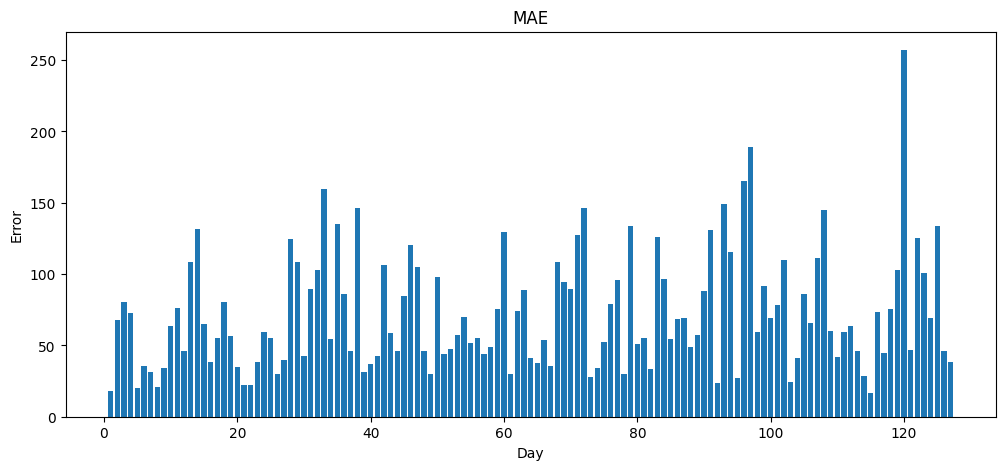

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA1)+1), real_loss_POA1)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

In [ ]:
def list_r2(y_true, y_pred):
  r2_list=[]
  for day in range(y_true.shape[0]):
    r2_list.append(r2_score(y_true[day,:],y_pred[day,:]))
  return r2_list

POA1

In [ ]:
real_r2_POA1=list_r2(yR_POA_Rear_test[:,:,0],predict_POA1_p1[:,:,0])
print(np.mean(real_r2_POA1))

-12.170224872727214


In [ ]:
print(real_r2_POA1)

[0.952169550322131, -939.2010701388537, 0.5907921219778758, 0.5446935581468986, 0.9715980590089749, 0.8823657080583037, 0.557431230103658, 0.9417552206455378, -2.685406730472288, 0.9630491114557268, 0.9170084729271887, -5.251748884469484, 0.31459400086925615, -31.36723749241613, -6.896868302004783, 0.6227040216543027, 0.6489663981508391, 0.8593023420297867, 0.8503816902069717, 0.921229642561924, 0.9790684673355102, 0.3949659664788503, 0.9323363761372544, 0.648935901104992, 0.893946945730823, 0.97849027273149, -10.620457040954781, 0.21257512774512433, -2.1315063991875607, 0.4423250094025405, 0.2913256166466732, -3.741110199474595, -8.726548675353683, 0.3331202392806992, -14.912371313593168, 0.6771537049898322, 0.7622498811074796, -11.656897157870816, -286.79551263107123, 0.3854750313607165, 0.9567045727614808, -0.5167410996035453, -0.7547144393922569, 0.862486783714947, 0.3118528583546405, -4.491283511983996, -1.1690305947354012, 0.9018813595306595, 0.9860585129614501, 0.588238244121657

POA2

In [ ]:
real_r2_POA2=list_r2(yR_POA_Rear_test[:,:,1],predict_POA1_p1[:,:,1])
print(np.mean(real_r2_POA2))

-121.13735691262347


In [ ]:
print(real_r2_POA2)

[0.9593274157523376, -3353.087332685762, 0.48121559193304386, 0.4844527019392115, 0.9474495891713727, 0.9123718205568282, 0.5162384959899786, 0.9209117644674824, -3.2096705854531296, 0.9448587245033884, 0.898084361535457, -6.302661584381943, 0.29192043909239695, -40.317668001252045, -8.322364671503262, 0.6051338702251174, 0.6571071623843924, 0.8454001264026212, 0.844984973248212, 0.9033488955220311, 0.9778281454357912, 0.3002316596482395, 0.9185041418174059, 0.593804579528489, 0.864237543388773, 0.9772912657773211, -13.03874230612659, 0.20744138898535092, -2.316309114439027, 0.4361172987361588, 0.2746073891696884, -4.6630392061151555, -10.479975849233437, 0.31219516445981477, -17.116145269948266, 0.7969391489706361, 0.774121698374284, -13.641388800009917, -11628.705064818252, 0.3346587173370814, 0.9589348488556125, -0.6005640550629321, -1.0643178467788377, 0.8693684403581268, 0.15393989808970687, -5.8483844878422495, -1.5951866852692946, 0.9148607357833471, 0.98596486751811, 0.59079320

Rear1

In [ ]:
real_r2_Rear1=list_r2(yR_POA_Rear_test[:,:,2],predict_POA1_p1[:,:,2])
print(np.mean(real_r2_Rear1))

-4.042543122113973


In [ ]:
print(real_r2_Rear1)

[0.8904123412634304, 0.22326137865109108, 0.08654034441243785, 0.5405649359775102, 0.6793709735424786, 0.7661234104444026, 0.1478313387468344, 0.8722996267095272, -0.011890573959975725, 0.9520557541766392, 0.8909125854612452, -1.9542042638026076, 0.1695504473702628, -37.05818629690956, -22.39080554419185, -0.006051258600579423, 0.649624502004149, 0.5267766147595379, 0.4591495582998074, 0.7700737782392608, 0.8022702225644551, 0.7740144560816169, 0.9085856715740839, 0.6607699733874712, 0.875670873462255, 0.9311363408192391, -54.69364102079747, 0.29158388192030227, -0.8867121774293871, 0.49478724002110774, 0.2610283343921779, -2.3603749783921226, -27.241631788070332, 0.2804910566279436, -9.674970984387098, 0.675349979067088, 0.8133728740730238, -6.386919751822548, 0.337169945884613, 0.263308948868231, 0.9306810220262263, -0.4010695111065894, -2.6646607730070317, 0.8250581403408853, 0.46215580333149464, -2.1834339202478845, -0.17597329799346983, 0.9421100992820128, 0.9096911322604954, 0.55

Rear2

In [ ]:
real_r2_Rear2=list_r2(yR_POA_Rear_test[:,:,3],predict_POA1_p1[:,:,3])
print(np.mean(real_r2_Rear2))

-20.25140894942872


In [ ]:
print(real_r2_Rear2)

[0.25314419037584746, -0.13482914874313412, 0.08053014991706031, 0.6204122029397439, 0.8161482801253431, 0.883683042064497, -0.1677133892826319, 0.9353370941121137, -2.4608762320845656, 0.8458243332436792, 0.9261350420848232, -9.004684117410921, -0.13227975704228068, -227.70373030440186, -38.4047447916977, -0.0029601699967793937, 0.9005848423474334, 0.7619758958013899, 0.7119620015988822, 0.9416286945109128, 0.9533067245600365, 0.4727588344775334, 0.9095941418415929, 0.09803530775367475, 0.6752976124674419, 0.7478852980566412, -226.62264972288773, -0.14286418695483594, -6.175899967091828, 0.05457309610476768, -0.17187096783666167, -12.617178618510513, -151.43946092075896, -0.07061239594727331, -46.65521666858455, 0.045152213267218855, 0.8878808600406958, -35.19503848592547, 0.16438501903400016, -0.14201348930776714, 0.7936467406398617, -0.6601583374012414, -2.0619533621685564, 0.4827221542333694, -1.5656208115924404, -14.207494640524782, -4.406530232353672, 0.8344458680152509, 0.713942

Rear3

In [ ]:
real_r2_Rear3=list_r2(yR_POA_Rear_test[:,:,4],predict_POA1_p1[:,:,4])
print(np.mean(real_r2_Rear3))

-8.041612533024539


In [ ]:
print(real_r2_Rear3)

[0.5215772900772984, -0.05872756402947288, 0.1408471228558813, 0.6882822795649222, 0.9060387434291444, 0.9218648063759474, -0.07445016937077908, 0.9153428445257227, -1.5736358442796328, 0.929393730295088, 0.918777361121604, -5.367232945889638, -0.09642506456940159, -78.49789190105392, -9.366326431413823, 0.017194340827036525, 0.9087040832931479, 0.7609721702127097, 0.7024615071980342, 0.9240115452408637, 0.9513598851801361, 0.5140610718467821, 0.9378121634073381, 0.3884388280121053, 0.7816638585490386, 0.8891377325948318, -36.397218418394615, -0.09539183084629466, -4.188621633277908, 0.12152849361317863, -0.11632172954635722, -6.627290210838488, -46.95242170858856, -0.048633590013804406, -27.488696165126612, 0.26884281036590485, 0.8096247406017137, -20.502171538698875, 0.17768742539181548, 0.1254588538151339, 0.907661739958418, -0.3683441939155243, -0.8889872047838645, 0.7415353887727942, -0.2558605332396555, -8.046817253552478, -2.6179765203098424, 0.8948104376840862, 0.85712961447433

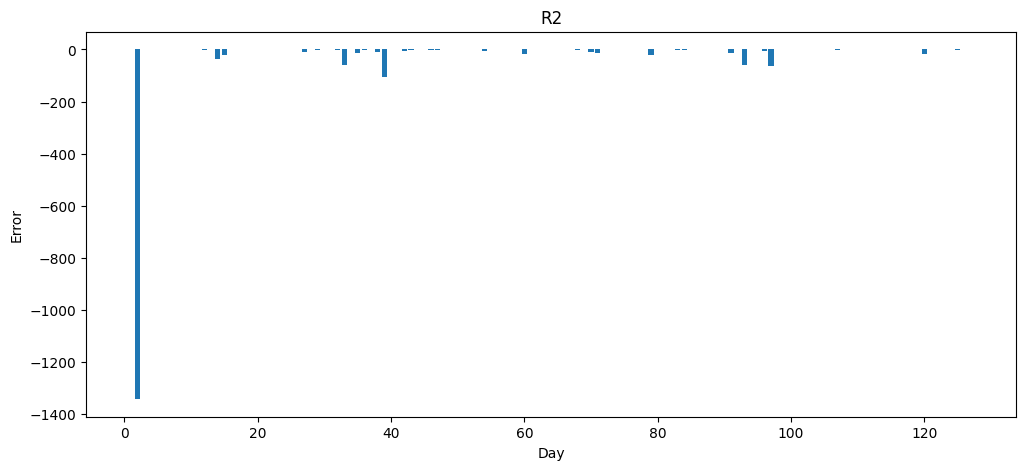

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA1)+1), real_r2_POA1)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

MAPE

In [ ]:
def mape_mod(y_true, y_pred):
  mape_list=[]

  for day in range(y_true.shape[0]):
    y_pred2=[]
    y_true2=[]
    for i in range(0,96):
      if y_true[day,i]>=5 and y_pred[day,i]>=2:
        y_true2.append(y_true[day,i])
        y_pred2.append(y_pred[day,i])
    mape_list.append(np.mean(np.abs((np.array(y_true2) - np.array(y_pred2)) / np.array(y_true2))))
  return mape_list

POA1

In [ ]:
real_mape_poa1=mape_mod(yR_POA_Rear_test[:,:,0],predict_POA1_p1[:,:,0])
print(np.mean(real_mape_poa1))

1.5044289776605104


In [ ]:
print(real_mape_poa1)

[np.float64(0.5053493556052783), np.float64(22.207267019309718), np.float64(1.8551757113054501), np.float64(1.2153476561076515), np.float64(0.4403410679347868), np.float64(0.6096089904088028), np.float64(2.332499030306589), np.float64(0.5384365382952844), np.float64(1.9985898629902754), np.float64(0.3755386884663879), np.float64(0.3960603903951392), np.float64(2.427261825302542), np.float64(0.8174318848911714), np.float64(4.7195320858544765), np.float64(3.5695581486450556), np.float64(0.6795659432800623), np.float64(1.1347331068389468), np.float64(0.7977811062198263), np.float64(0.4621443802366294), np.float64(0.6606634737648186), np.float64(0.49253462001481535), np.float64(0.8143414831786872), np.float64(0.3510255082221805), np.float64(0.7658036428728598), np.float64(0.5516159887043054), np.float64(0.36525709264666456), np.float64(4.4479499142476895), np.float64(0.7053122608075446), np.float64(2.43046353741472), np.float64(0.4840874891982618), np.float64(0.6432853314138901), np.float6

POA2

In [ ]:
real_mape_poa2=mape_mod(yR_POA_Rear_test[:,:,1],predict_POA1_p1[:,:,1])
print(np.mean(real_mape_poa2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_poa2)

[np.float64(0.5544639079065237), np.float64(20.174659592181442), np.float64(3.050154150718308), np.float64(1.3310791603270877), np.float64(0.6147024436681996), np.float64(0.5568230797118355), np.float64(3.7975893552688236), np.float64(0.6786944513818277), np.float64(2.2544815917295082), np.float64(0.4763310092298054), np.float64(0.48956622647157455), np.float64(2.6134053731527445), np.float64(0.7989196006489315), np.float64(5.327782673323765), np.float64(3.335567302448397), np.float64(0.507125438262564), np.float64(1.1608252236437433), np.float64(0.5798442329648796), np.float64(0.417144678386971), np.float64(0.6876806874215952), np.float64(0.32786044394958463), np.float64(0.7457375812378659), np.float64(0.31909013975246764), np.float64(0.8307368929359231), np.float64(0.4172516731670939), np.float64(0.3331780322319039), np.float64(5.447213703245074), np.float64(0.6880502150586496), np.float64(2.263924519891166), np.float64(0.4417047042454897), np.float64(0.6167686658897877), np.float64(

Rear1

In [ ]:
real_mape_rear1=mape_mod(yR_POA_Rear_test[:,:,2],predict_POA1_p1[:,:,2])
print(np.mean(real_mape_rear1))

0.9651041840286324


In [ ]:
print(real_mape_rear1)

[np.float64(0.264969303613931), np.float64(0.7069855679051886), np.float64(0.8051829608734173), np.float64(0.43743825967442934), np.float64(0.5042998777108594), np.float64(0.3255810521686397), np.float64(0.7176092829461097), np.float64(0.2967181388481643), np.float64(0.9483596995795275), np.float64(0.14166107456875587), np.float64(0.25470827174776944), np.float64(1.4617910512983983), np.float64(0.6740098437806852), np.float64(4.695551429998068), np.float64(1.5989608367694543), np.float64(0.8371439923695514), np.float64(0.43651393555291856), np.float64(0.5569826935297822), np.float64(0.6088551386366021), np.float64(0.4014923507993112), np.float64(0.32928416621140605), np.float64(0.33251751888376896), np.float64(0.25048499159573684), np.float64(0.6675518381071612), np.float64(0.3940479935417786), np.float64(0.21687780576055837), np.float64(1.1467463900348047), np.float64(0.7280668047449896), np.float64(1.4251875366603726), np.float64(0.4998223481094711), np.float64(0.6422810573560284), n

Rear2

In [ ]:
real_mape_rear2=mape_mod(yR_POA_Rear_test[:,:,3],predict_POA1_p1[:,:,3])
print(np.mean(real_mape_rear2))

nan


In [ ]:
print(real_mape_rear2)

[np.float64(0.8144367131840037), np.float64(0.7453263331114686), np.float64(0.8210700990990254), np.float64(0.4333861387711461), np.float64(0.37270880943401075), np.float64(0.251621806752082), np.float64(0.8323280865079487), np.float64(0.1860083858076051), np.float64(2.0273001249713807), np.float64(0.2716785550085337), np.float64(0.17614510254213164), np.float64(2.6458195186292324), np.float64(0.840537271202639), np.float64(2.6884810368427328), np.float64(nan), np.float64(0.8486760624758605), np.float64(0.2397538302909039), np.float64(0.39523164465976524), np.float64(0.4511778862043354), np.float64(0.20618183500855555), np.float64(0.15770335817928297), np.float64(0.36724721394764925), np.float64(0.21028860370432081), np.float64(1.2726247056126663), np.float64(0.5314569050738787), np.float64(0.43722832968591735), np.float64(nan), np.float64(0.8386101545744313), np.float64(2.739676224126477), np.float64(0.7104512315804716), np.float64(0.8347071360225085), np.float64(3.602535745875814), n

Rear3

In [ ]:
real_mape_rear3=mape_mod(yR_POA_Rear_test[:,:,4],predict_POA1_p1[:,:,4])
print(np.mean(real_mape_rear3))

nan


In [ ]:
print(real_mape_rear3)

[np.float64(0.5851912634795818), np.float64(0.8034980149622167), np.float64(0.8024734626696246), np.float64(0.4907446737711482), np.float64(0.2849766414978665), np.float64(0.27197489841902595), np.float64(0.8378949223797649), np.float64(0.21361380159570184), np.float64(1.6257252251638172), np.float64(0.23186148691863118), np.float64(0.23325050473346032), np.float64(2.1502549200461996), np.float64(0.8434770052959414), np.float64(3.7028328507114727), np.float64(0.15403300553177215), np.float64(0.841426301737053), np.float64(0.24957984557445875), np.float64(0.4277817726577613), np.float64(0.4822770701856519), np.float64(0.2659050260555221), np.float64(0.20860138130657327), np.float64(0.3680137677391452), np.float64(0.22115368347013847), np.float64(0.955356700149932), np.float64(0.5947288959964024), np.float64(0.2921243539424523), np.float64(nan), np.float64(0.8657796441679139), np.float64(2.312340125749968), np.float64(0.7231895584721094), np.float64(0.8413616603430278), np.float64(2.6069

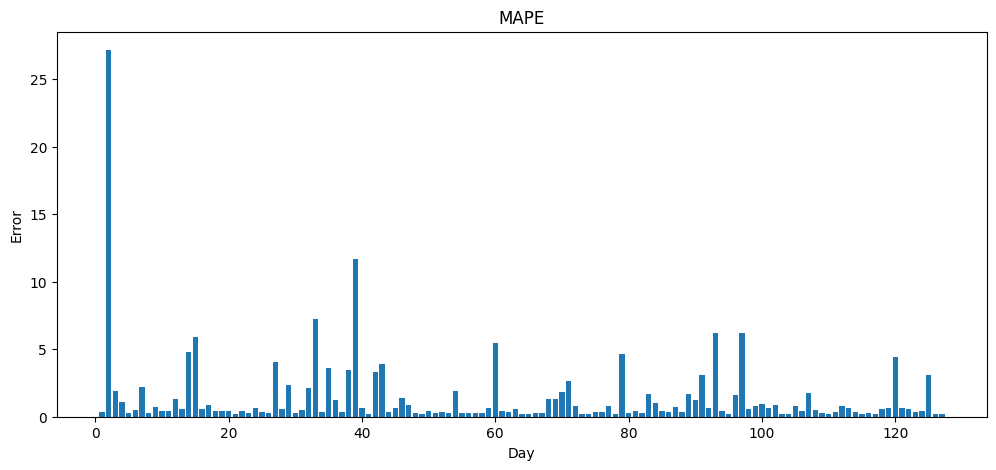

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa1)+1), real_mape_poa1)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Check the graphs to understand atypical errors

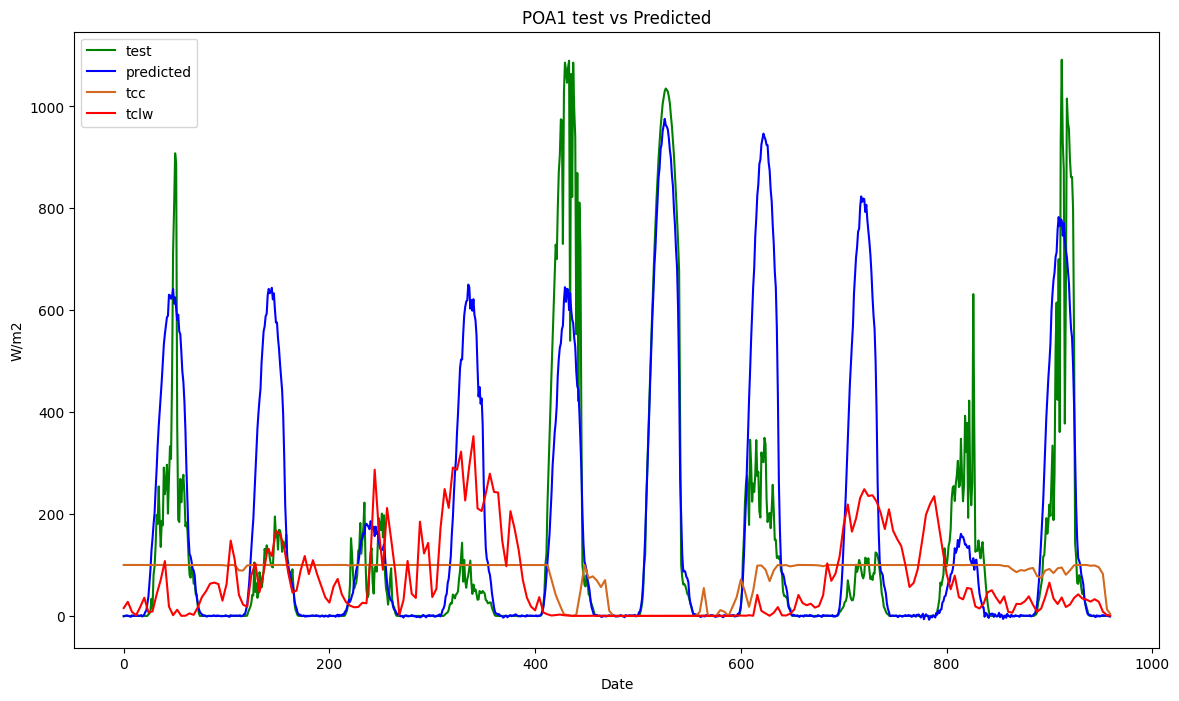

In [ ]:
plt.figure(figsize=(14,8))
st_day=90
end_day=100
dat_clouds=yR_POA_Rear_test.shape[0]*yR_POA_Rear_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA_Rear_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA1_p1.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Model summary

In [ ]:
model1_POA_Rear_GRU4.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 384, 128)  │     56,832 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 128)  │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     37,248 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │     15,456 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 480)       │     46,560 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 96, 5)     │          0 │ Irr_output[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 493,730 (1.88 MB)

 Trainable params: 164,576 (642.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 329,154 (1.26 MB)

In case you need to retrain a model based on the results of keras tuner

In [ ]:
X1_POA_Rear_train=np.concatenate((X1_POA_Rear_train,X1_POA_Rear_val),axis=0)
y1_POA_Rear_train=np.concatenate((y1_POA_Rear_train,y1_POA_Rear_val),axis=0)

surf_Rear_train=np.concatenate((surf_Rear_train,surf_Rear_val),axis=0)

print(X1_POA_Rear_train.shape)
print(y1_POA_Rear_train.shape)
print(surf_Rear_train.shape)

(1141, 384, 18)
(1141, 96, 5)
(1141, 4)


In [ ]:
def create_poa_rear(X,y,epochs,learning_rate1,cb):
    seq_input = keras.layers.Input(shape=(obs_window, (13+n_exo_var)), name='seq-input')

    x = keras.layers.GRU(128,return_sequences=True, activation='tanh')(seq_input)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.GRU(64,return_sequences=False)(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.Dense(128, activation='relu')(x)

    surf_input = keras.layers.Input(shape=(4,), name='surf-input')
    s = keras.layers.Dense(32, activation='relu')(surf_input)

    comb = Concatenate()([x, s])
    comb = keras.layers.Dense(96, activation='relu')(comb)

    output = keras.layers.Dense(5 * win_size, activation='linear', name='Irr_output')(comb)
    output = keras.layers.Reshape((win_size, 5))(output)

    model = keras.models.Model(inputs=[seq_input, surf_input], outputs=output)

    # Compilación
    model.compile(
        optimizer=Adam(learning_rate=learning_rate1),
        loss='mae',metrics=['mae', 'mse', 'mape'])


    model.fit(X,y,epochs=epochs,callbacks=[cb])
    return model

In [ ]:
model1_POA_Rear_GRU4_v2=create_poa_rear([X1_POA_Rear_train, surf_Rear_train],y1_POA_Rear_train,100,0.001,check_point_poa1)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0731 - mae: 0.0731 - mape: 134.7747 - mse: 0.0265
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0406 - mae: 0.0406 - mape: 67.6716 - mse: 0.0100
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0312 - mae: 0.0312 - mape: 51.1727 - mse: 0.0055
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0296 - mae: 0.0296 - mape: 45.4012 - mse: 0.0053
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0292 - mae: 0.0292 - mape: 43.3531 - mse: 0.0054
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0285 - mae: 0.0285 - mape: 41.5650 - mse: 0.0053
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0281 - mae: 0.0281 - mape: 40.1997 - mse: 0.0052
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0276 - mae: 0.0276 - mape: 38.3135 - mse: 0.0051
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0275 - mae: 0.0275 - mape: 36.9869 - mse: 0.0051


In [ ]:
model1_POA_Rear_GRU4_v2=load_model("model_checkpoint/best_model_poa1.keras")

Save the model

In [ ]:
model1_POA_Rear_GRU4_v2.save('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA_Rear_n5_v2.keras')

Load model

In [ ]:
model1_POA_Rear_GRU4_v2=keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/models_GRU_MMS/model_GRU4_POA_Rear_n5_v2.keras')

Prediction and evaluation

In [ ]:
pred_POA1_p1_v2=model1_POA_Rear_GRU4_v2.predict([X1_POA_Rear_test,surf_Rear_test])
predict_POA1_p1_v2=np.zeros_like(pred_POA1_p1_v2)
scalers=[scaler_POA1, scaler_POA2, scaler_Rear1, scaler_Rear2, scaler_Rear3]
for p in range(0,5):
  predict_POA1_p1_v2[:,:,p]=(scalers[p].inverse_transform(pred_POA1_p1_v2[:,:,p].reshape(-1,1))).reshape(pred_POA1_p1_v2[:,:,p].shape[0],pred_POA1_p1_v2[:,:,p].shape[1])


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


POA1

In [ ]:
real_loss_POA1_v2=list_mae(yR_POA_Rear_test[:,:,0],predict_POA1_p1_v2[:,:,0])
print(np.mean(real_loss_POA1_v2))

79.9134598951715


In [ ]:
print(real_loss_POA1_v2)

[15.922260792487378, 43.67223893708217, 74.83567027896616, 74.49876860951629, 21.528618324854012, 36.26443957867542, 32.63898577252562, 27.35287876911259, 88.42196674104298, 35.46001710417669, 45.013103767267495, 90.80544798559315, 110.93603126574708, 132.57509206159216, 36.331442635309934, 73.97884630255898, 65.67322430082362, 46.04329433910191, 94.22413477530138, 36.45622276913659, 18.041349604275208, 14.971459826106434, 27.13107789179561, 66.12155449143194, 40.23431923305271, 17.936708836993155, 34.44932828425299, 153.29607370377215, 119.44740301884514, 53.763422836601215, 113.47775486744429, 127.65273164045807, 68.82558865802615, 73.79542362081135, 149.33316182285486, 28.17727322807055, 71.68416104368339, 160.84218827089424, 84.8757688025298, 56.0573373653395, 26.424870254265795, 62.93287115749803, 67.37924454805146, 55.593953777089745, 105.84466652245483, 157.14087359764244, 136.8449060714299, 45.51638742486193, 27.41395427539084, 130.76587703703737, 23.08603755157988, 57.03043818

POA2

In [ ]:
real_loss_POA2_v2=list_mae(yR_POA_Rear_test[:,:,1],predict_POA1_p1_v2[:,:,1])
print(np.mean(real_loss_POA2_v2))

77.0456946501765


In [ ]:
print(real_loss_POA2_v2)

[16.58529416716193, 41.50373273213804, 85.54730043611399, 78.18004619348498, 24.421618967398334, 34.02016020220904, 30.65179675357827, 29.9415235854617, 90.48074607131376, 33.17591718150209, 42.349164710190905, 92.24105190875837, 109.46616374785786, 132.36525667937212, 34.68873842344896, 68.56101957157908, 64.13369589195511, 46.516660955254025, 92.46167348441531, 38.1127339786743, 18.653043872613406, 11.804291344907613, 27.033567170645906, 68.57714954132832, 39.80337598378604, 17.752812685661695, 33.19185157991853, 147.1649162057185, 116.30520627486858, 51.693891332201055, 110.83454148153658, 127.63275167835756, 65.85418209213111, 75.72193649011923, 146.590659360226, 23.77840422724049, 62.12061810969943, 156.9336905685283, 80.05248173048459, 58.911255190273124, 26.19058317475263, 60.55793549773248, 64.75139750165026, 52.273559925677695, 107.85048264835764, 153.2501147445281, 130.41554456994368, 41.1743738976724, 25.379662916844747, 128.9454721624413, 22.248186515301864, 57.083637107081

Rear1

In [ ]:
real_loss_Rear1_v2=list_mae(yR_POA_Rear_test[:,:,2],predict_POA1_p1_v2[:,:,2])
print(np.mean(real_loss_Rear1_v2))

8.445720060615155


In [ ]:
print(real_loss_Rear1_v2)

[1.8399599975765575, 10.440297495695782, 27.362514279865792, 14.797602506308243, 14.984315324349097, 9.326639332466259, 11.322988910034072, 6.5271926403351515, 5.138261379460208, 3.9394289264239095, 4.56177630525276, 6.557545941883376, 8.62060371480428, 9.891707138567273, 6.646837050585268, 40.62412109001526, 15.289536068045459, 15.82461737938928, 18.854976721433257, 10.028558941882364, 8.292233292287875, 1.5771835884591914, 4.46312693561033, 5.228523002499034, 3.993400925905712, 2.8849891207715572, 6.158146070583126, 9.003629340390175, 7.996852453748764, 3.728439958834508, 6.868740865989557, 8.906642894953563, 9.104043534088296, 3.9815600107615814, 11.402735386678481, 5.645158415385988, 5.695961106728383, 12.031415831967005, 3.4820425102696393, 8.503679572050908, 2.365311666823016, 6.789568536217267, 10.136374573062959, 5.21636729962598, 7.582826455065525, 10.603086123239502, 8.934774271852856, 3.3751275325067716, 2.5005837680117424, 9.947600965075035, 2.7968827238334053, 4.5361145726

Rear2

In [ ]:
real_loss_Rear2_v2=list_mae(yR_POA_Rear_test[:,:,3],predict_POA1_p1_v2[:,:,3])
print(np.mean(real_loss_Rear2_v2))

7.096871698037349


In [ ]:
print(real_loss_Rear2_v2)

[2.8844005379138475, 5.782074229087869, 19.622535554960624, 10.254729944566106, 11.946435507407193, 7.2727834578669315, 8.757154075217835, 2.958067627011804, 5.110744200608646, 1.8174758024516837, 2.414673869211542, 6.207168426193692, 6.189902722807271, 8.249893980699484, 5.731790066416283, 31.967155074436203, 7.799739155545995, 9.268751102177825, 10.929389164571782, 5.438719874552528, 3.6928654372676326, 1.6330826660445383, 1.6648539856398088, 4.3490809368867245, 2.832091018137515, 1.5629042941333646, 4.990330225186557, 6.312172557906731, 7.569380980829334, 3.952535035333568, 4.218552202641421, 8.607022338234687, 8.45229105638224, 3.055550161902614, 10.83503019355562, 6.623025627480653, 3.5317367377792146, 11.596027143443571, 5.925607365711261, 8.266377655399507, 2.7475594539063657, 5.3611851666162105, 9.710333769952578, 4.421778599558807, 7.318478993291087, 9.985131645083372, 9.63914681167858, 3.6746347129365815, 1.8938244835123494, 7.147636185240007, 1.6231719198662578, 3.3134783664

Rear3

In [ ]:
real_loss_Rear3_v2=list_mae(yR_POA_Rear_test[:,:,4],predict_POA1_p1_v2[:,:,4])
print(np.mean(real_loss_Rear3_v2))

8.212110110416747


In [ ]:
print(real_loss_Rear3_v2)

[3.1156832667861725, 7.188237446899344, 19.458457544843636, 8.694213376694524, 9.345057838761354, 5.339763804535271, 8.280849789482804, 3.295615731475467, 5.719518014089633, 3.211332345497117, 3.782848872393217, 6.689968424639446, 7.507221313842746, 9.299246644217472, 6.720775611149894, 34.75771544923539, 7.4918982036687325, 10.052155510910081, 12.304062622281167, 6.907629256281743, 5.354706619510176, 1.8999262086408724, 3.671234511471061, 5.407227583248776, 4.10124488165545, 2.439813972450359, 6.042089029957476, 9.102144221920598, 8.335583751329917, 3.854181610442088, 5.841568708274245, 9.125018483315861, 9.057073915676703, 3.259222497924045, 11.81667093314625, 6.8452194701307745, 6.412350271306706, 12.628228201818395, 5.675138627863592, 9.012885273442995, 2.4699812011794626, 6.216300333303647, 10.651931891341087, 5.9002218624033596, 7.805413608439731, 10.739341095979228, 10.15381747976243, 4.008957124387581, 2.7491877528532727, 10.559217766682687, 3.289201952550112, 4.04214944038666,

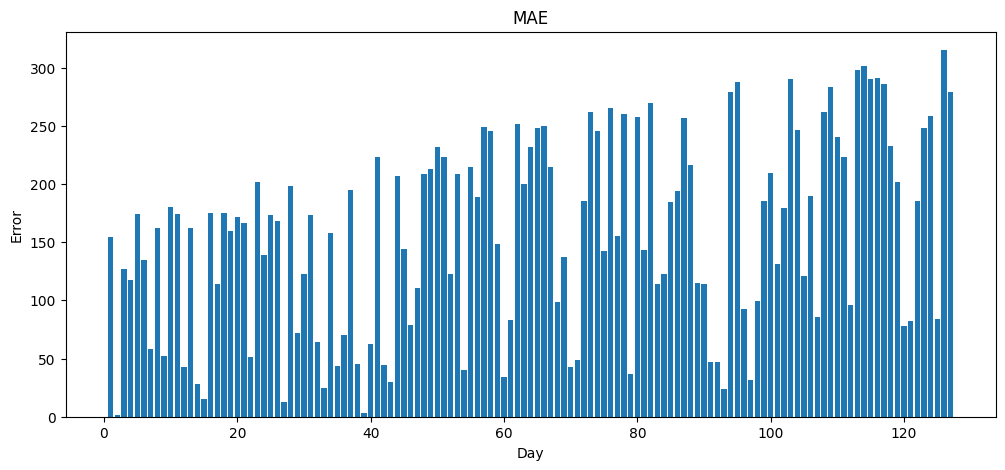

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_loss_POA1_v2)+1), real_loss_POA1_v2)
plt.title("MAE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

R2

POA1

In [ ]:
real_r2_POA1_v2=list_r2(yR_POA_Rear_test[:,:,0],predict_POA1_p1_v2[:,:,0])
print(np.mean(real_r2_POA1_v2))

-13.079732716881377


In [ ]:
print(real_r2_POA1_v2)

[0.9807708138978851, -542.2997522050117, 0.6900391533377059, 0.5225239109239275, 0.9721654292726857, 0.8863097365454943, 0.5553423558775035, 0.944464088601289, -2.8911220332666376, 0.9411048256555374, 0.8991561745758437, -5.002137967333283, 0.3388282875894032, -35.54101333242778, -5.867347379247753, 0.7791809359804489, 0.6316593115847298, 0.9162769670390486, 0.4988047071617482, 0.9239974907452445, 0.9812455507239307, 0.8058371458510162, 0.9593330824487273, 0.570303458861084, 0.8922858065123086, 0.9765580776219722, -7.445931280051353, 0.14291246741278663, -2.6087352119670757, 0.6019455522161359, 0.3541218615543815, -4.439642687600189, -9.853934983266335, 0.6323433176134244, -14.616918973824163, 0.7185158782985217, 0.8136177745364105, -14.003945272483493, -719.2095647656016, 0.2079814580474021, 0.9738177639512736, -1.4954274870599282, -3.868748940605588, 0.8319792535731856, 0.20241482408504774, -6.152721459422735, -1.8193063191946468, 0.9205836577480107, 0.9753936054193578, 0.51927929832

POA2

In [ ]:
real_r2_POA2_v2=list_r2(yR_POA_Rear_test[:,:,1],predict_POA1_p1_v2[:,:,1])
print(np.mean(real_r2_POA2_v2))

-238.8597764272703


In [ ]:
print(real_r2_POA2_v2)

[0.9768959538822245, -1916.4807940398089, 0.4903649743853037, 0.45415406933642366, 0.9588419712165387, 0.8964267165986735, 0.5394388290235138, 0.9342854820491776, -3.7442697541602445, 0.9415866007257077, 0.9048109184668635, -6.364348812901801, 0.317109204540192, -47.2259427467735, -6.920064085993995, 0.778767117584833, 0.6137827400918603, 0.9062274169327703, 0.48690625409822597, 0.9118185840911646, 0.9808370971156789, 0.8688861961319291, 0.9523787904771331, 0.518642733031848, 0.8801910808518071, 0.975916535494821, -9.14531999349719, 0.14271638364369144, -2.862484032703623, 0.5777936243842883, 0.33440723962143737, -5.544030637938392, -11.466426191620807, 0.5909078814187914, -16.95196331237556, 0.7304496977227801, 0.8160806305761968, -16.307277369705748, -27935.048949832788, 0.17813607181433844, 0.9720762321691471, -1.6080158256369286, -4.793778843229199, 0.8260816246028997, 0.00747670186037952, -7.716349757992642, -2.2770800797914794, 0.9224264650939841, 0.9788196269964173, 0.4903325987

Rear1

In [ ]:
real_r2_Rear1_v2=list_r2(yR_POA_Rear_test[:,:,2],predict_POA1_p1_v2[:,:,2])
print(np.mean(real_r2_Rear1_v2))

-5.673972864219574


In [ ]:
print(real_r2_Rear1_v2)

[0.9722320449511481, 0.35692192449731097, 0.260951240642153, 0.4713882752715889, 0.5854526533365256, 0.726479267479677, 0.3481415572608543, 0.84721337970506, 0.12160216080203134, 0.9182245100637293, 0.8794558008611402, -1.239134332340114, 0.5421168135209551, -32.26352281953246, -54.43808651784468, 0.10421241206538445, 0.580900075837429, 0.5530481581077364, 0.22230747595168476, 0.721396652634356, 0.7604571216091754, 0.9380777328349205, 0.9158885511215724, 0.7055986489461861, 0.8924484054898975, 0.9550463789988202, -96.89532513792047, 0.5115701800150539, -0.4600044215647141, 0.8498498611684755, 0.6938323238359142, -2.0151578162004817, -45.767390738077204, 0.853721556924457, -7.334276936960514, -0.2744622106348269, 0.8460285048479983, -5.930097272343109, 0.8705837439485676, -2.8010832065712963, 0.9828120224821005, -1.019110916694868, -18.244012240263437, 0.8414035744762058, 0.47630005607063386, -2.2327148774376524, -0.15251729864468233, 0.9445641315788778, 0.9797942280218861, 0.6686653627

Rear2

In [ ]:
real_r2_Rear2_v2=list_r2(yR_POA_Rear_test[:,:,3],predict_POA1_p1_v2[:,:,3])
print(np.mean(real_r2_Rear2_v2))

-39.78909126680634


In [ ]:
print(real_r2_Rear2_v2)

[0.8633806100793637, 0.43413992651979405, 0.3236945737934278, 0.4842337519001132, 0.5920982713184529, 0.7364000648273561, 0.3230330719896517, 0.9415188670803981, -1.1011891851843347, 0.9682382373833844, 0.9387580349805182, -4.311649048231759, 0.5596176118795151, -126.4802886640152, -573.3853492849909, 0.1210039960402598, 0.7292234315135726, 0.6946346872510644, 0.372174066090069, 0.8345793315113479, 0.8996792393955579, 0.701649897240087, 0.976723566932437, 0.5984614793116032, 0.8841969947876219, 0.9759723676568346, -1716.8581008721055, 0.5440390927647003, -1.9298026785378988, 0.6938727185627687, 0.7917943919565337, -5.645383679933316, -332.65603102115756, 0.8535004316497159, -21.194088763573124, -3.7962728945066866, 0.8776766883171053, -18.642242505076993, -1.0159623400669466, -5.392010088671656, 0.9536718074189996, -2.3555184349758993, -58.47278310636188, 0.7971585268260198, 0.05255296196108494, -5.879474521324095, -1.6322048484691756, 0.8954807145663626, 0.9793249854720749, 0.72821889

Rear3

In [ ]:
real_r2_Rear3_v2=list_r2(yR_POA_Rear_test[:,:,4],predict_POA1_p1_v2[:,:,4])
print(np.mean(real_r2_Rear3_v2))

-12.629657543536162


In [ ]:
print(real_r2_Rear3_v2)

[0.9058126743103111, 0.4354737214949791, 0.38624664908155715, 0.6195300725097515, 0.7467998315796669, 0.8546997038085858, 0.40479405683776304, 0.9378306552277542, -0.6710357074097768, 0.9386526647492037, 0.8982363392923379, -2.486930983656615, 0.6140330456402834, -48.02174662675729, -154.60282556334928, 0.13334338927965983, 0.7795074264352289, 0.7092402660450251, 0.4072640269812873, 0.821640561467677, 0.8724481331729197, 0.7760037831924411, 0.9365846865876631, 0.6708060640205956, 0.8703971885299694, 0.9675884759606084, -299.0423872510438, 0.47879155019535635, -1.3330242100679448, 0.7978985310842271, 0.7361191813144201, -2.9420323940011897, -99.48016385350948, 0.9005715560539673, -13.248761789497896, -1.5295719464540207, 0.7893862739822237, -11.50794934632446, -0.05030017167469114, -3.0409334749553905, 0.9770880535963338, -1.5922846379082372, -34.642177578603146, 0.8312210689380596, 0.4802787554752802, -3.391094523649775, -0.8372249689163485, 0.9371920603302222, 0.9748195800976792, 0.64

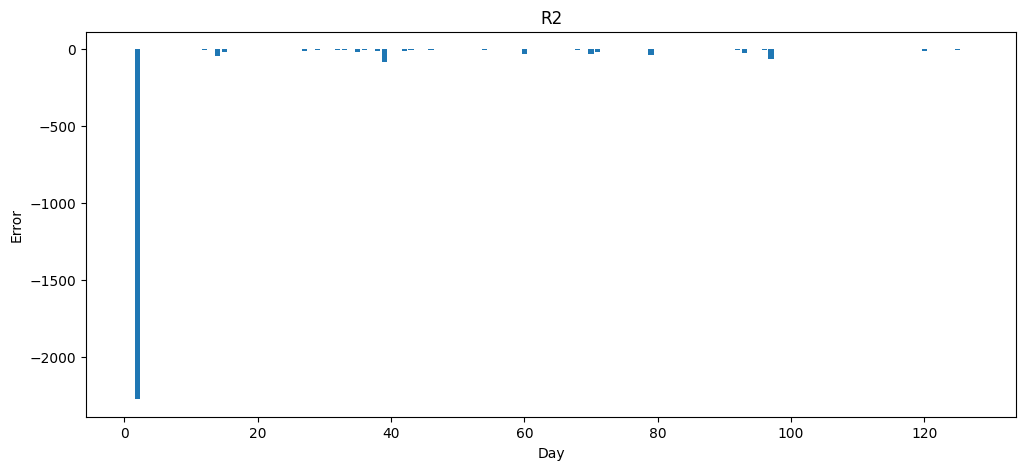

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_r2_POA1_v2)+1), real_r2_POA1_v2)
plt.title("R2")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Mape

POA1

In [ ]:
real_mape_poa1_v2=mape_mod(yR_POA_Rear_test[:,:,0],predict_POA1_p1_v2[:,:,0])
print(np.mean(real_mape_poa1_v2))

1.6511912532966602


In [ ]:
print(real_mape_poa1_v2)

[np.float64(0.28137868064345867), np.float64(16.967040449181013), np.float64(2.2757216330107797), np.float64(1.1380359995951446), np.float64(0.3551765742329574), np.float64(0.5514804504653413), np.float64(1.8202856364652324), np.float64(0.4302639517946071), np.float64(1.9295066016013764), np.float64(0.31117139201194793), np.float64(0.31619427871462363), np.float64(2.2397838938023593), np.float64(0.716786643411904), np.float64(5.071609683324878), np.float64(3.363905880054748), np.float64(0.6432103800834924), np.float64(1.1423139157046505), np.float64(0.7790289439336094), np.float64(0.5285813845467161), np.float64(0.658750430044505), np.float64(0.4478067341568687), np.float64(0.3335537919891639), np.float64(0.31808170159959115), np.float64(0.8317943314152768), np.float64(0.47774030829561626), np.float64(0.32631895249942017), np.float64(3.554285087742849), np.float64(0.7062854650289547), np.float64(2.7015741644468623), np.float64(0.32892987237873295), np.float64(0.5548873927516482), np.fl

POA2

In [ ]:
real_mape_poa2_v2=mape_mod(yR_POA_Rear_test[:,:,1],predict_POA1_p1_v2[:,:,1])
print(np.mean(real_mape_poa2_v2))

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(real_mape_poa2_v2)

[np.float64(0.32087371027807216), np.float64(17.47857251527642), np.float64(4.0470041522898805), np.float64(1.2431018952119113), np.float64(0.3998219715956566), np.float64(0.5495900926409494), np.float64(2.814460275902648), np.float64(0.5077326154752), np.float64(2.136006606676487), np.float64(0.2883879114163242), np.float64(0.2979028125811074), np.float64(2.49440180178972), np.float64(0.7117564098645165), np.float64(5.700062738024486), np.float64(3.10574787705216), np.float64(0.39293168877020235), np.float64(1.2365968875074644), np.float64(0.5810542451025739), np.float64(0.542396681804016), np.float64(0.7076449523833788), np.float64(0.3495596312021896), np.float64(0.272948396855416), np.float64(0.3076316716534348), np.float64(0.9255780345138894), np.float64(0.4124871566450136), np.float64(0.34623863042497005), np.float64(4.528068924866577), np.float64(0.6922342177772333), np.float64(2.541896162007926), np.float64(0.33502275974802515), np.float64(0.5260486833773541), np.float64(3.19498

Rear1

In [ ]:
real_mape_rear1_v2=mape_mod(yR_POA_Rear_test[:,:,2],predict_POA1_p1_v2[:,:,2])
print(np.mean(real_mape_rear1_v2))

1.0343794990065642


In [ ]:
print(real_mape_rear1_v2)

[np.float64(0.14764894295881556), np.float64(0.5432554049865147), np.float64(0.7145787318814287), np.float64(0.4981207449321399), np.float64(0.5678165968935784), np.float64(0.4264200413610237), np.float64(0.6077760992420331), np.float64(0.34865078343228023), np.float64(0.8869398242501874), np.float64(0.2614369458405695), np.float64(0.2989880004374648), np.float64(1.298552911046006), np.float64(0.5030760711258215), np.float64(4.169966294829242), np.float64(3.235243373089611), np.float64(0.7737858814655034), np.float64(0.5077844800311743), np.float64(0.510212720501182), np.float64(0.695479844654083), np.float64(0.43756976128513014), np.float64(0.41283831484588823), np.float64(0.19594371286767434), np.float64(0.2708023065880748), np.float64(0.6060102190872174), np.float64(0.3531708983395715), np.float64(0.19587880348712267), np.float64(3.4779005841826383), np.float64(0.604010615093412), np.float64(1.1711077503394527), np.float64(0.4038710606597349), np.float64(0.4601259128640514), np.floa

Rear2

In [ ]:
real_mape_rear2_v2=mape_mod(yR_POA_Rear_test[:,:,3],predict_POA1_p1_v2[:,:,3])
print(np.mean(real_mape_rear2_v2))

nan


In [ ]:
print(real_mape_rear2_v2)

[np.float64(0.3761764711428253), np.float64(0.4430920816157387), np.float64(0.6696074538359547), np.float64(0.4268925769017766), np.float64(0.5551370443219122), np.float64(0.41798844303107097), np.float64(0.5978937060242332), np.float64(0.21748761054881066), np.float64(1.5736622509117888), np.float64(0.14601143447300688), np.float64(0.22531365709132162), np.float64(1.806215291053232), np.float64(0.44184060078581017), np.float64(2.2294162217036706), np.float64(nan), np.float64(0.7569669301120161), np.float64(0.374009176139252), np.float64(0.47822731916741773), np.float64(0.6630040656020126), np.float64(0.3638334209207789), np.float64(0.244215383359), np.float64(0.4117606186926892), np.float64(0.12256922100135278), np.float64(0.877473825958914), np.float64(0.349872199472476), np.float64(0.14300530536084793), np.float64(nan), np.float64(0.5711910191050209), np.float64(1.7509542586737912), np.float64(0.7551250251113552), np.float64(0.3413430391641729), np.float64(2.4234787035499763), np.fl

Rear3

In [ ]:
real_mape_rear3_v2=mape_mod(yR_POA_Rear_test[:,:,4],predict_POA1_p1_v2[:,:,4])
print(np.mean(real_mape_rear3_v2))

nan


In [ ]:
print(real_mape_rear3_v2)

[np.float64(0.26287018460335654), np.float64(0.4534420370023207), np.float64(0.647882728551771), np.float64(0.4186738621994331), np.float64(0.4652351086787814), np.float64(0.2991070971533513), np.float64(0.5279176409753517), np.float64(0.22166527710010506), np.float64(1.347972632851885), np.float64(0.2397513926642532), np.float64(0.24686823899163912), np.float64(1.5300051246195447), np.float64(0.47750982366720696), np.float64(2.321903671093571), np.float64(4.174466677292894), np.float64(0.7476856421905494), np.float64(0.3256209048631074), np.float64(0.4428741388028613), np.float64(0.649458518948253), np.float64(0.3580529409800933), np.float64(0.3109754226843476), np.float64(0.34811111723395094), np.float64(0.22875062772664362), np.float64(0.7115278256755448), np.float64(0.42714601649449646), np.float64(0.15904034378225904), np.float64(nan), np.float64(0.6178603277343322), np.float64(1.503219806013326), np.float64(0.5559607303994354), np.float64(0.4016300986950796), np.float64(1.8287019

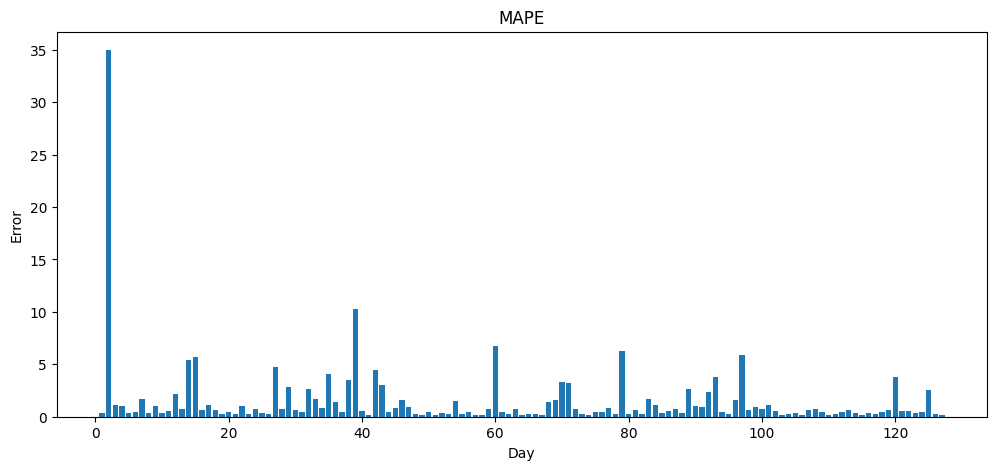

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(range(1, len(real_mape_poa1_v2)+1), real_mape_poa1_v2)
plt.title("MAPE")
plt.xlabel("Day")
plt.ylabel("Error")
plt.show()

Model summary

In [ ]:
model1_POA_Rear_GRU4_v2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq-input           │ (None, 384, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 384, 128)  │     56,832 │ seq-input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 128)  │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     37,248 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surf-input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ surf-input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │     15,456 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Irr_output (Dense)  │ (None, 480)       │     46,560 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 96, 5)     │          0 │ Irr_output[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 493,730 (1.88 MB)

 Trainable params: 164,576 (642.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 329,154 (1.26 MB)

Check the graphs to understand atypical errors

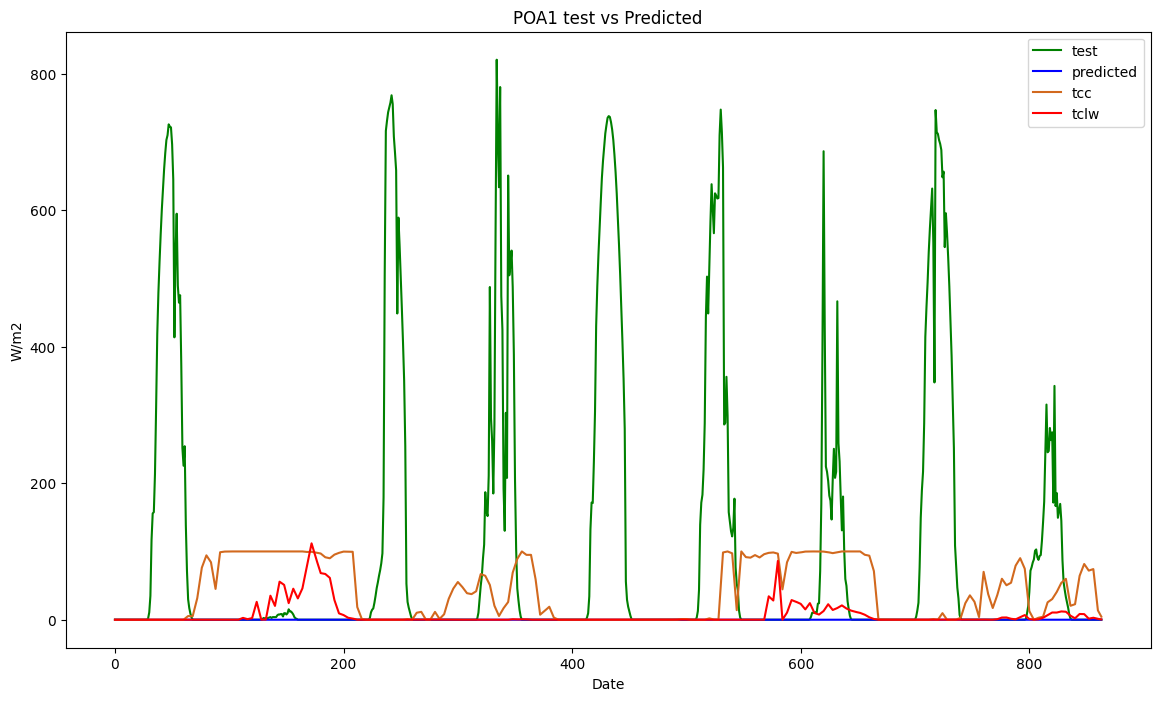

In [ ]:
plt.figure(figsize=(14,8))
st_day=1
end_day=10
dat_clouds=yR_POA_Rear_test.shape[0]*yR_POA_Rear_test.shape[1]
i_clouds=len(df3)-dat_clouds+(st_day-1)*96
f_clouds=i_clouds+(end_day-st_day)*96
plt.plot(yR_POA_Rear_test.reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='test',color='green')
plt.plot(predict_POA1_p1_v2[:,:,0].reshape(-1,1)[(st_day-1)*win_size:(end_day-1)*win_size],label='predicted',color='blue')
plt.plot(df3['tcc'].values[i_clouds:f_clouds],label='tcc',color='chocolate')
plt.plot(df3['tclw'].values[i_clouds:f_clouds]*300,label='tclw',color='red')
plt.title("POA1 test vs Predicted")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()